<a href="https://colab.research.google.com/github/tomas-kaunas/Money/blob/main/pinigai.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import tensorflow as tf
from tensorflow import keras
import seaborn as sns
import os
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

In [ ]:
import yfinance as yf
ticker = "META"
start_date = "2010-01-10"
end_date = "2025-09-10" #jeigu neturi duomenu end datui nieko neivyksta tom dienom tiesiog

data = yf.download(ticker, start=start_date, end=end_date)
data = data.reset_index()
ohlcv = data[['Date', 'Open', 'High', 'Low', 'Close', 'Volume']]
ohlcv.to_csv("AAPL_OHLCV.csv")
data = pd.read_csv("AAPL_OHLCV.csv", parse_dates=["Date"]) #parse dates i datetime objects pavercia

cols = ['Open', 'High', 'Low', 'Close', 'Volume']
data[cols] = data[cols].apply(pd.to_numeric, errors='coerce') #panaikina $, p-avercia i floata
print(data.info())

[*********************100%***********************]  1 of 1 completed

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3347 entries, 0 to 3346
Data columns (total 7 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   Price   3347 non-null   object        
 1   Date    3346 non-null   datetime64[ns]
 2   Open    3346 non-null   float64       
 3   High    3346 non-null   float64       
 4   Low     3346 non-null   float64       
 5   Close   3346 non-null   float64       
 6   Volume  3346 non-null   float64       
dtypes: datetime64[ns](1), float64(5), object(1)
memory usage: 183.2+ KB
None


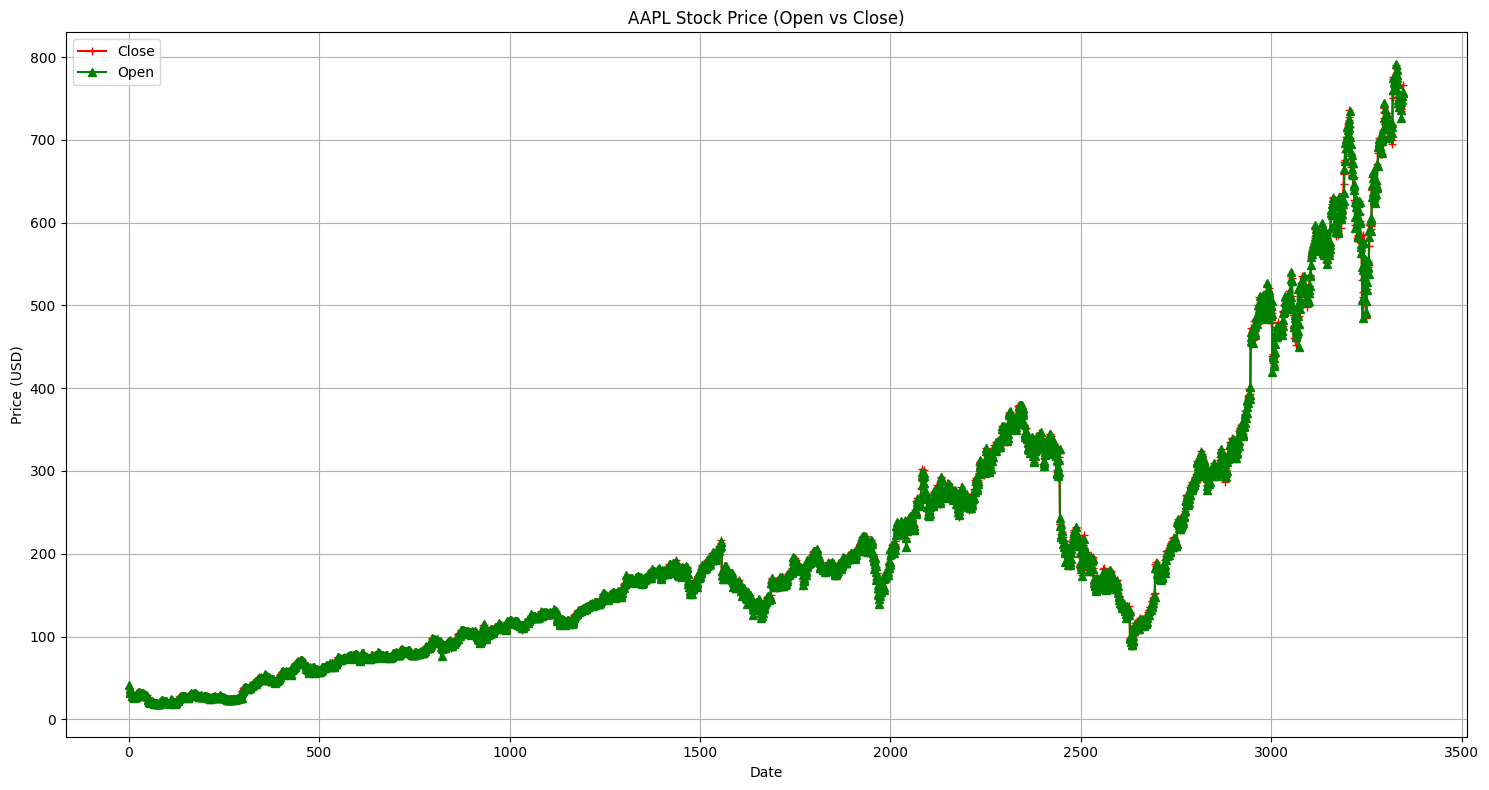

In [ ]:

plt.figure(figsize=(15, 8))
plt.plot(data.index, data['Close'], color="red", label="Close", marker="+")
plt.plot(data.index, data['Open'], color="green", label="Open", marker="^")
plt.title("AAPL Stock Price (Open vs Close)")
plt.xlabel("Date")
plt.ylabel("Price (USD)")
plt.legend()
plt.grid()
plt.tight_layout()
plt.show()


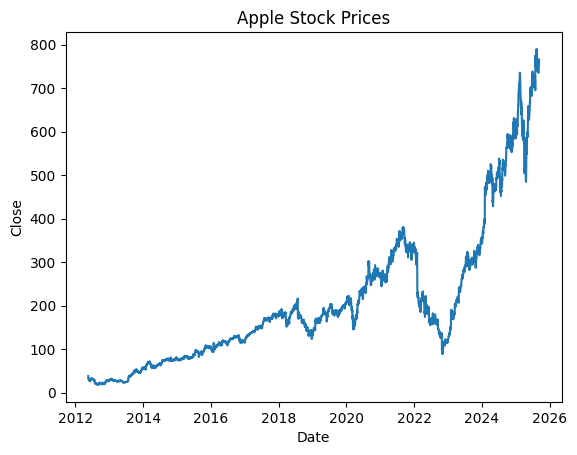

In [ ]:

apple = data
prediction_range = apple.loc[(apple['Date'] > datetime(2013,1,1)) #.loc paselectina ta row kuri pasepsifyini
 & (apple['Date']<datetime(2018,1,1))]
plt.plot(apple['Date'], apple['Close'])
plt.xlabel("Date")
plt.ylabel("Close")
plt.title("Apple Stock Prices")
plt.show()

In [ ]:
apple = apple[1:]
close_data = apple.filter(['Close']) #paima tik close reiksmes
dataset = close_data.values # i numpy pavercia
training = int(np.ceil(len(dataset) * .95))
print(dataset)

[[ 38.02140808]
 [ 33.84432602]
 [ 30.83086014]
 ...
 [752.45001221]
 [752.29998779]
 [765.70001221]]


In [ ]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler(feature_range=(0, 1)) #pascalina visas reiksmes taro 0 ir 1, tam kad lstm geriau veiktu
scaled_data = scaler.fit_transform(dataset) #.fit transorm atlieka scalerio funkcija, dabar cia normalizuota data bus

train_data = scaled_data[0:int(training), :] #paima 95 procentus traininimui, , : reiskia kad visus stulpelius paima
# prepare feature and labels
x_train = []
y_train = []
#print(dataset[:, 0])
for i in range(60, len(train_data)):  #naudosim paksutines 60 dienu kad predictint dabartines
    x_train.append(train_data[i-60:i, 0]) #paima 60 dienu pries (i nesistaikciuoja tai paima nuo i-60 iki i-1)
    y_train.append(train_data[i, 0]) #paima i stulpeli
    #abu paima pirma stulpeli(tik jis vienas ir yra)(jei nebutu to nulio butu 2d o mum reik 1d)

x_train, y_train = np.array(x_train), np.array(y_train) # is listo i np array, nes reikia layeriam
print(x_train.shape)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1)) #lstm reikia 3d (samples, timesteps, features) uztai

(3119, 60)


In [ ]:
model = keras.models.Sequential()
model.add(keras.layers.LSTM(units=64,
                            return_sequences=True,
                            input_shape=(x_train.shape[1], 1)))
model.add(keras.layers.LSTM(units=64))
model.add(keras.layers.Dense(32))
model.add(keras.layers.Dropout(0.5))
model.add(keras.layers.Dense(1))
model.summary

<bound method Model.summary of <Sequential name=sequential, built=True>>

In [ ]:
model.compile(optimizer='adam',
              loss='mean_squared_error')
history = model.fit(x_train,
                    y_train,
                    epochs=25)

Epoch 1/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 5s 11ms/step - loss: 0.0176
Epoch 2/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.0029
Epoch 3/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0024
Epoch 4/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0022
Epoch 5/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0020
Epoch 6/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0019
Epoch 7/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016
Epoch 8/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0015
Epoch 9/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0013
Epoch 10/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0016
Epoch 11/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0014
Epoch 12/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0012
Epoch 13/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 2s 11ms/step - loss: 0.0011
Epoch 14/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0011
Epoch 15/25
98/98 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0011
Epoch 16/25
98/9

In [ ]:
test_data = scaled_data[training - 60:, :] #paima 60 dienu anksciau pries norima data
x_test = []
y_test = dataset[training:, :]
for i in range(60, len(test_data)):
    x_test.append(test_data[i-60:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

predictions = model.predict(x_test) #kai lstmas predictina 5 diena, jis naudoja senas predixtintas dienas kaip real data
predictions = scaler.inverse_transform(predictions) #reikia atgal rescalint i normalias vertes

mse = np.mean(((predictions - y_test) ** 2))
rmse = np.sqrt(mse)

print("MSE", mse)
print("RMSE", np.sqrt(mse))

6/6 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step
MSE 533.6541180868583
RMSE 23.100954917207606


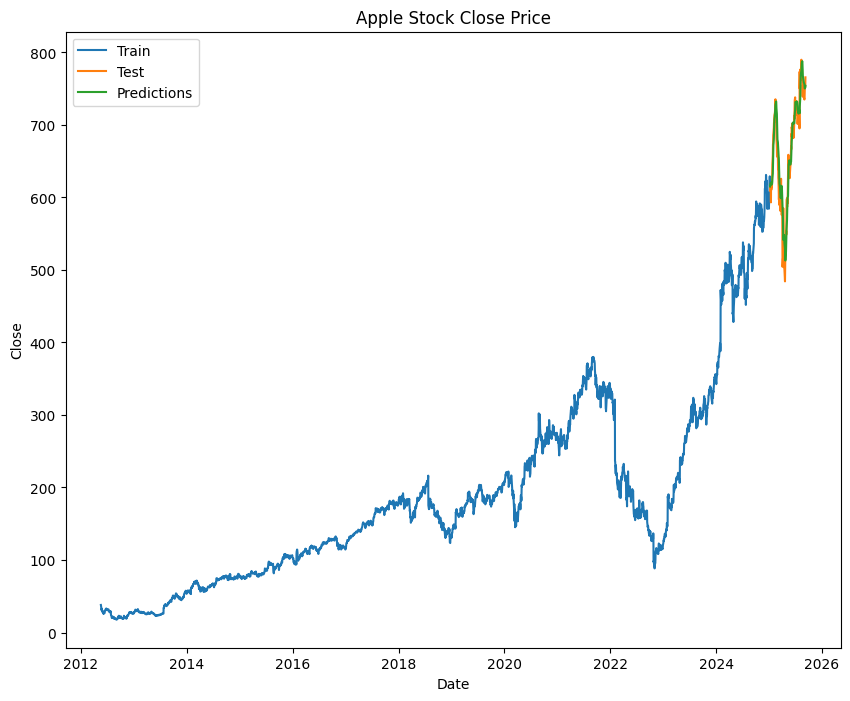

In [ ]:
train = apple[:training]
test = apple[training:]
test['Predictions'] = predictions #prideda dar viena stulpeli

plt.figure(figsize=(10, 8))
plt.plot(train['Date'], train['Close'])
plt.plot(test['Date'], test[['Close', 'Predictions']])
plt.title('Apple Stock Close Price')
plt.xlabel('Date')
plt.ylabel("Close")
plt.legend(['Train', 'Test', 'Predictions'])

In [ ]:

test = [scaled_data[-59:, :]]
test = np.array(test)
test = np.reshape(test, (test.shape[0], test.shape[1], 1))
prediction = model.predict(test)
prediction = scaler.inverse_transform(prediction)

'''#Reshape prediction to match LSTM input format
pred_reshaped = prediction.reshape(1, 1, 1)  # shape: (1, 1, 1)

#Append prediction to the end, remove oldest value from the start
test = np.concatenate((test[:, 1:, :], pred_reshaped), axis=1)
prediction = model.predict(test)
#prediction = scaler.inverse_transform(prediction)
prediction = scaler.inverse_transform(prediction)'''
print(prediction)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 28ms/step
[[758.14]]
